In [4]:
from IPython.display import Markdown, display

display(Markdown("""
# Tsunami Evacuation Environment Workflow

This notebook builds the first GIS environment for tsunami evacuation modeling from the local road network, TAZ layer, and the scanned tsunami hazard map.
"""))


# Tsunami Evacuation Environment Workflow

This notebook builds the first GIS environment for tsunami evacuation modeling from the local road network, TAZ layer, and the scanned tsunami hazard map.


In [5]:
from pathlib import Path
import os

import cv2
import geopandas as gpd
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage, display
from PIL import Image
from shapely.geometry import LineString, Polygon

display(pd.DataFrame({"package": ["geopandas", "numpy", "pandas", "opencv"], "status": ["loaded"] * 4}))

,package,status
0,geopandas,loaded
1,numpy,loaded
2,pandas,loaded
3,opencv,loaded


In [6]:
MANUAL_PROJECT_ROOT = Path(r"C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינוי")


def looks_like_project_root(candidate: Path) -> bool:
    if not candidate.exists() or not candidate.is_dir():
        return False
    has_image = (candidate / "tel aviv tsunami event.jpg").exists()
    try:
        has_roads = any(child.is_dir() and (child / "section.shp").exists() for child in candidate.iterdir())
    except PermissionError:
        has_roads = False
    return has_image and has_roads


def find_project_root(start: Path, fallback: Path) -> Path:
    candidates = [start, *start.parents, fallback]
    for candidate in candidates:
        if looks_like_project_root(candidate):
            return candidate.resolve()
    raise FileNotFoundError(f"Could not locate the project root. Update MANUAL_PROJECT_ROOT. Current value: {fallback}")


PROJECT_ROOT = find_project_root(Path.cwd(), MANUAL_PROJECT_ROOT)
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

display(pd.DataFrame({"name": ["PROJECT_ROOT", "OUTPUT_DIR"], "path": [PROJECT_ROOT, OUTPUT_DIR]}))

,name,path
0,PROJECT_ROOT,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינוי
1,OUTPUT_DIR,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...


In [7]:
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))
os.environ.setdefault("MPLBACKEND", "module://matplotlib_inline.backend_inline")
(PROJECT_ROOT / ".matplotlib").mkdir(exist_ok=True)

import matplotlib.pyplot as plt

display(pd.DataFrame({"setting": ["MPLCONFIGDIR", "MPLBACKEND"], "value": [os.environ["MPLCONFIGDIR"], os.environ["MPLBACKEND"]]}))

,setting,value
0,MPLCONFIGDIR,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...
1,MPLBACKEND,module://matplotlib_inline.backend_inline


In [8]:
def find_data_dir(project_root: Path) -> Path:
    for child in project_root.iterdir():
        if child.is_dir() and (child / "section.shp").exists():
            return child
    raise FileNotFoundError(f"Could not find a data directory with section.shp under {project_root}")


DATA_DIR = find_data_dir(PROJECT_ROOT)
IMAGE_PATH = PROJECT_ROOT / "tel aviv tsunami event.jpg"

display(pd.DataFrame({"name": ["DATA_DIR", "IMAGE_PATH"], "path": [DATA_DIR, IMAGE_PATH]}))

,name,path
0,DATA_DIR,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...
1,IMAGE_PATH,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...


In [9]:
EPSG_ITM = 2039

frame = {
    "left": 92,
    "right": 950,
    "top": 33,
    "bottom": 1999,
}

extent = {
    "xmin": 170_000.0,
    "xmax": 185_000.0,
    "ymin": 645_000.0,
    "ymax": 684_000.0,
}

line_simplify_m = 15.0

display(pd.DataFrame([frame | extent | {"line_simplify_m": line_simplify_m, "crs": f"EPSG:{EPSG_ITM}"}]))

,left,right,top,bottom,xmin,xmax,ymin,ymax,line_simplify_m,crs
0,92,950,33,1999,170000.0,185000.0,645000.0,684000.0,15.0,EPSG:2039


,width_px,height_px,mode
0,1000,2033,RGB


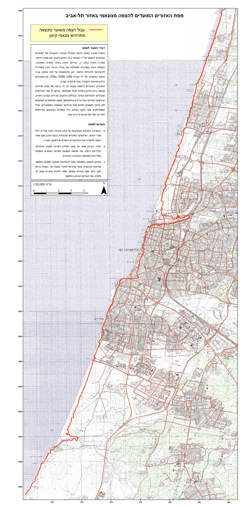

In [10]:
image = Image.open(IMAGE_PATH).convert("RGB")
image_array = np.array(image)

display(pd.DataFrame({"width_px": [image.width], "height_px": [image.height], "mode": [image.mode]}))
display(image.resize((250, int(250 * image.height / image.width))))

In [11]:
red_mask = (
    (image_array[:, :, 0] > 165)
    & (image_array[:, :, 1] < 120)
    & (image_array[:, :, 2] < 120)
    & ((image_array[:, :, 0] - image_array[:, :, 1]) > 70)
    & ((image_array[:, :, 0] - image_array[:, :, 2]) > 70)
).astype("uint8")

red_pixels = int(red_mask.sum())
ys, xs = np.where(red_mask == 1)

display(pd.DataFrame({
    "red_pixels": [red_pixels],
    "min_x_px": [int(xs.min())],
    "min_y_px": [int(ys.min())],
    "max_x_px": [int(xs.max())],
    "max_y_px": [int(ys.max())],
}))

,red_pixels,min_x_px,min_y_px,max_x_px,max_y_px
0,9995,101,34,949,1997


In [12]:
component_count, labels, stats, centroids = cv2.connectedComponentsWithStats(red_mask, 8)
component_rows = []
for label in range(1, component_count):
    x, y, width, height, area = stats[label]
    component_rows.append({
        "label": label,
        "area_px": int(area),
        "x_min_px": int(x),
        "y_min_px": int(y),
        "x_max_px": int(x + width - 1),
        "y_max_px": int(y + height - 1),
        "centroid_x_px": float(centroids[label][0]),
        "centroid_y_px": float(centroids[label][1]),
    })

components = pd.DataFrame(component_rows).sort_values("area_px", ascending=False)
largest_red_label = int(components.iloc[0]["label"])
boundary_mask = labels == largest_red_label

display(components.head(10))

,label,area_px,x_min_px,y_min_px,x_max_px,y_max_px,centroid_x_px,centroid_y_px
0,1,7405,101,34,900,1980,552.751789,1013.556516
16,17,107,355,118,408,119,381.747664,118.504673
92,93,7,795,376,795,382,795.000000,379.000000
524,525,6,694,908,694,913,694.000000,910.500000
1963,1964,6,632,1861,637,1861,634.500000,1861.000000
88,89,5,839,367,840,370,839.600000,368.800000
1505,1506,5,679,1490,679,1494,679.000000,1492.000000
1592,1593,5,504,1542,505,1545,504.200000,1543.200000
670,671,4,854,1008,857,1008,855.500000,1008.000000
339,340,4,714,751,715,754,714.250000,752.500000


In [13]:
def pixel_to_itm(px: float, py: float) -> tuple[float, float]:
    x = extent["xmin"] + ((px - frame["left"]) / (frame["right"] - frame["left"])) * (extent["xmax"] - extent["xmin"])
    y = extent["ymax"] - ((py - frame["top"]) / (frame["bottom"] - frame["top"])) * (extent["ymax"] - extent["ymin"])
    return x, y


display(pd.DataFrame({
    "pixel": ["top-left", "bottom-right"],
    "itm": [pixel_to_itm(frame["left"], frame["top"]), pixel_to_itm(frame["right"], frame["bottom"])],
}))

,pixel,itm
0,top-left,"(170000.0, 684000.0)"
1,bottom-right,"(185000.0, 645000.0)"


In [14]:
boundary_pixels = []
for py in range(frame["top"], frame["bottom"] + 1):
    row_xs = np.flatnonzero(boundary_mask[py, frame["left"] : frame["right"] + 1])
    if row_xs.size:
        boundary_pixels.append((frame["left"] + float(np.median(row_xs)), float(py)))

boundary_coords = [pixel_to_itm(px, py) for px, py in boundary_pixels]
hazard_boundary_line = LineString(boundary_coords).simplify(line_simplify_m, preserve_topology=False)

display(pd.DataFrame({"boundary_pixel_rows": [len(boundary_pixels)], "boundary_vertices": [len(hazard_boundary_line.coords)]}))

,boundary_pixel_rows,boundary_vertices
0,1947,264


In [15]:
line_coords = list(hazard_boundary_line.coords)
hazard_polygon = Polygon([
    (extent["xmin"], extent["ymax"]),
    line_coords[0],
    *line_coords[1:],
    (extent["xmin"], extent["ymin"]),
])

if not hazard_polygon.is_valid:
    hazard_polygon = hazard_polygon.buffer(0)

hazard_boundary = gpd.GeoDataFrame({"source": ["local_jpg_red_boundary"]}, geometry=[hazard_boundary_line], crs=f"EPSG:{EPSG_ITM}")
hazard_area = gpd.GeoDataFrame({"source": ["local_jpg_west_of_red_boundary"]}, geometry=[hazard_polygon], crs=f"EPSG:{EPSG_ITM}")

display(pd.DataFrame({"hazard_area_sq_km": [hazard_polygon.area / 1_000_000], "is_valid": [hazard_polygon.is_valid]}))
display(hazard_area)

,hazard_area_sq_km,is_valid
0,304.092556,True


,source,geometry
0,local_jpg_west_of_red_boundary,"POLYGON ((170000 684000, 184117.133 683980.163..."


In [16]:
def read_layer(name: str) -> gpd.GeoDataFrame:
    path = DATA_DIR / name
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f"{path} has no CRS")
    return gdf.to_crs(EPSG_ITM)


roads = read_layer("section.shp")
nodes = read_layer("nodes.shp")
taz = read_layer("TAZ_v4.22_ITM.shp")

layer_summary = pd.DataFrame({
    "layer": ["roads", "nodes", "taz"],
    "rows": [len(roads), len(nodes), len(taz)],
    "crs": [roads.crs, nodes.crs, taz.crs],
    "bounds": [tuple(round(float(v), 1) for v in layer.total_bounds) for layer in [roads, nodes, taz]],
})

display(layer_summary)

,layer,rows,crs,bounds
0,roads,28691,EPSG:2039,"(174778.1, 639402.5, 197022.2, 686288.5)"
1,nodes,15784,EPSG:2039,"(174953.5, 640449.5, 196465.1, 685376.3)"
2,taz,1310,EPSG:2039,"(163531.3, 629094.0, 205083.4, 702107.1)"


In [17]:
roads_hazard = roads[roads.geometry.intersects(hazard_polygon)].copy()
roads_clipped = gpd.clip(roads, hazard_area).reset_index(drop=True)
nodes_hazard = nodes[nodes.geometry.within(hazard_polygon)].copy()
taz_hazard = taz[taz.geometry.intersects(hazard_polygon)].copy()

for layer in [roads_hazard, roads_clipped, nodes_hazard, taz_hazard]:
    layer["in_tsunami_hazard"] = True

hazard_counts = pd.DataFrame({
    "layer": ["road_sections_hazard", "road_sections_clipped", "nodes_hazard", "taz_hazard"],
    "rows": [len(roads_hazard), len(roads_clipped), len(nodes_hazard), len(taz_hazard)],
})

display(hazard_counts)

,layer,rows
0,road_sections_hazard,720
1,road_sections_clipped,720
2,nodes_hazard,370
3,taz_hazard,68


In [18]:
sample_columns = [column for column in ["id", "eid", "name", "layer", "in_tsunami_hazard"] if column in roads_hazard.columns]

display(roads_hazard[sample_columns + ["geometry"]].head())

,id,eid,name,layer,in_tsunami_hazard,geometry
1,241.0,1476,None,Roads,True,"LINESTRING (179915.917 667438.44, 180050.335 6..."
2,242.0,1476,None,Roads,True,"LINESTRING (180267.647 667509.665, 180263.306 ..."
4,244.0,1477,None,Roads,True,"LINESTRING (179909.415 667437.349, 179909.862 ..."
13,258.0,1487,None,Roads,True,"LINESTRING (179378.49 667340.023, 179380.827 6..."
14,259.0,1487,None,Roads,True,"LINESTRING (179369.994 667417.22, 179370.192 6..."


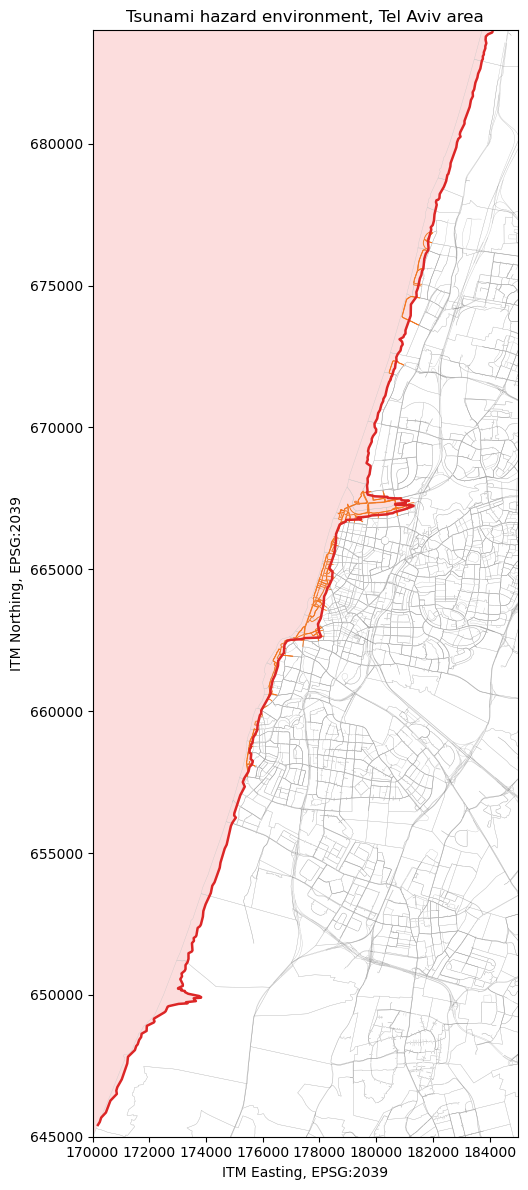

,saved_preview
0,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...


In [19]:
fig, ax = plt.subplots(figsize=(8, 12))
taz.boundary.plot(ax=ax, color="#c9c9c9", linewidth=0.25)
roads.plot(ax=ax, color="#737373", linewidth=0.25, alpha=0.45)
hazard_area.plot(ax=ax, facecolor="#ef4444", edgecolor="none", alpha=0.18)
roads_hazard.plot(ax=ax, color="#f97316", linewidth=0.65, alpha=0.95)
hazard_boundary.plot(ax=ax, color="#dc2626", linewidth=1.8)
ax.set_xlim(extent["xmin"], extent["xmax"])
ax.set_ylim(extent["ymin"], extent["ymax"])
ax.set_aspect("equal")
ax.set_title("Tsunami hazard environment, Tel Aviv area")
ax.set_xlabel("ITM Easting, EPSG:2039")
ax.set_ylabel("ITM Northing, EPSG:2039")
clean_preview_path = OUTPUT_DIR / "tsunami_environment_preview.png"
fig.tight_layout()
fig.savefig(clean_preview_path, dpi=180)

display(fig)
display(pd.DataFrame({"saved_preview": [clean_preview_path]}))
plt.close(fig)

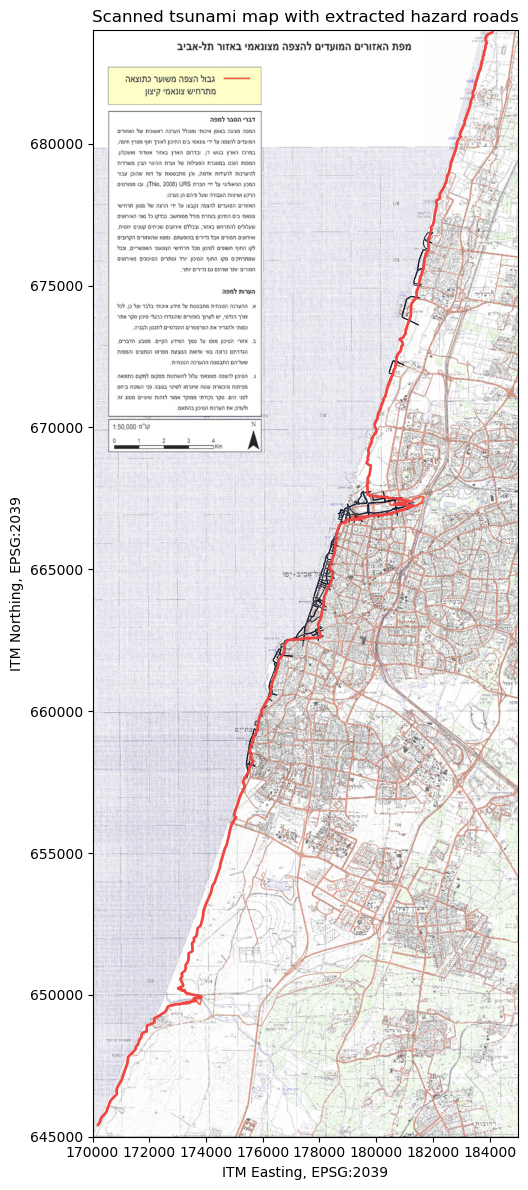

,saved_preview
0,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...


In [20]:
cropped_image = image_array[frame["top"] : frame["bottom"] + 1, frame["left"] : frame["right"] + 1]

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(
    cropped_image,
    extent=(extent["xmin"], extent["xmax"], extent["ymin"], extent["ymax"]),
    origin="upper",
    alpha=0.86,
)
roads_hazard.plot(ax=ax, color="#0f172a", linewidth=0.75, alpha=0.9)
hazard_boundary.plot(ax=ax, color="#ef4444", linewidth=1.8)
ax.set_xlim(extent["xmin"], extent["xmax"])
ax.set_ylim(extent["ymin"], extent["ymax"])
ax.set_aspect("equal")
ax.set_title("Scanned tsunami map with extracted hazard roads")
ax.set_xlabel("ITM Easting, EPSG:2039")
ax.set_ylabel("ITM Northing, EPSG:2039")
raster_preview_path = OUTPUT_DIR / "tsunami_raster_overlay_preview.png"
fig.tight_layout()
fig.savefig(raster_preview_path, dpi=180)

display(fig)
display(pd.DataFrame({"saved_preview": [raster_preview_path]}))
plt.close(fig)

In [21]:
gpkg_path = OUTPUT_DIR / "tsunami_environment.gpkg"
if gpkg_path.exists():
    gpkg_path.unlink()

layers_to_write = {
    "hazard_boundary": hazard_boundary,
    "hazard_area": hazard_area,
    "road_sections_hazard": roads_hazard,
    "road_sections_clipped": roads_clipped,
    "nodes_hazard": nodes_hazard,
    "taz_hazard": taz_hazard,
}

for layer_name, layer in layers_to_write.items():
    layer.to_file(gpkg_path, layer=layer_name, driver="GPKG")

display(pd.DataFrame({"layer": list(layers_to_write), "rows": [len(layer) for layer in layers_to_write.values()]}))
display(pd.DataFrame({"gpkg_path": [gpkg_path], "exists": [gpkg_path.exists()]}))

,layer,rows
0,hazard_boundary,1
1,hazard_area,1
2,road_sections_hazard,720
3,road_sections_clipped,720
4,nodes_hazard,370
5,taz_hazard,68


,gpkg_path,exists
0,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...,True


In [22]:
summary = pd.DataFrame([
    ("data_dir", str(DATA_DIR)),
    ("image", str(IMAGE_PATH)),
    ("hazard_area_sq_km", hazard_polygon.area / 1_000_000),
    ("road_sections_total", len(roads)),
    ("road_sections_hazard", len(roads_hazard)),
    ("road_sections_clipped", len(roads_clipped)),
    ("nodes_total", len(nodes)),
    ("nodes_hazard", len(nodes_hazard)),
    ("taz_total", len(taz)),
    ("taz_hazard", len(taz_hazard)),
    ("gpkg", str(gpkg_path)),
    ("clean_preview", str(clean_preview_path)),
    ("raster_preview", str(raster_preview_path)),
], columns=["metric", "value"])

summary_path = OUTPUT_DIR / "tsunami_environment_summary.csv"
summary_status = "written"
try:
    summary.to_csv(summary_path, index=False)
except PermissionError:
    summary_path = OUTPUT_DIR / "tsunami_environment_summary_notebook.csv"
    summary.to_csv(summary_path, index=False)
    summary_status = "fallback_written_because_default_csv_was_locked"

display(summary)
display(pd.DataFrame({"summary_path": [summary_path], "status": [summary_status]}))

,metric,value
0,data_dir,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...
1,image,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...
2,hazard_area_sq_km,304.092556
3,road_sections_total,28691
4,road_sections_hazard,720
5,road_sections_clipped,720
6,nodes_total,15784
7,nodes_hazard,370
8,taz_total,1310
9,taz_hazard,68


,summary_path,status
0,C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינו...,written


In [23]:
display(Markdown("""
# Mapping height evacuation options

Using TLV open maps
"""))


# Mapping height evacuation options

Using TLV open maps


In [24]:
from pathlib import Path

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

map1_path = OUTPUT_DIR / "tel_aviv_hazard_map.png"
map2_path = OUTPUT_DIR / "tel_aviv_hazard_with_refuge_buildings.png"

print(map1_path)
print(map2_path)

C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינוי\outputs\tel_aviv_hazard_map.png
C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינוי\outputs\tel_aviv_hazard_with_refuge_buildings.png


In [25]:
import requests
import geopandas as gpd
import pandas as pd
from pathlib import Path

folder = Path(r"C:\Users\idogr\Documents\אוניברסיטה\שנה ג\פינוי\קבצים")

# שכבת מבנים של עיריית תל אביב-יפו
buildings_url = "https://gisn.tel-aviv.gov.il/arcgis/rest/services/IView2/MapServer/513/query"

# נשתמש בגבולות אזור הסכנה אם כבר יש לך hazard_area
minx, miny, maxx, maxy = hazard_area.total_bounds

params = {
    "f": "geojson",
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
    "outSR": "2039",
    "geometry": f"{minx},{miny},{maxx},{maxy}",
    "geometryType": "esriGeometryEnvelope",
    "inSR": "2039",
    "spatialRel": "esriSpatialRelIntersects",
    "resultOffset": 0,
    "resultRecordCount": 2000
}

features = []

while True:
    r = requests.get(buildings_url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    
    batch = data.get("features", [])
    features.extend(batch)
    
    print("Downloaded:", len(features))
    
    if len(batch) < params["resultRecordCount"]:
        break
    
    params["resultOffset"] += params["resultRecordCount"]

buildings = gpd.GeoDataFrame.from_features(features, crs="EPSG:2039")

print("מספר מבנים שהורדו:", len(buildings))
print(buildings.columns)

display(buildings.head())

ConnectionError: HTTPSConnectionPool(host='gisn.tel-aviv.gov.il', port=443): Max retries exceeded with url: /arcgis/rest/services/IView2/MapServer/513/query?f=geojson&where=1%3D1&outFields=%2A&returnGeometry=true&outSR=2039&geometry=170000.0%2C645000.0%2C184117.13286713287%2C684000.0&geometryType=esriGeometryEnvelope&inSR=2039&spatialRel=esriSpatialRelIntersects&resultOffset=0&resultRecordCount=2000 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000196F5D8FB60>: Failed to resolve 'gisn.tel-aviv.gov.il' ([Errno 11001] getaddrinfo failed)"))

In [ ]:
buildings_path = folder / "tel_aviv_buildings.gpkg"

buildings.to_file(buildings_path, layer="buildings", driver="GPKG")

print("נשמר כאן:")
print(buildings_path)

In [ ]:
buildings = buildings.copy()

# המרה לערכים מספריים
buildings["ms_komot"] = pd.to_numeric(buildings["ms_komot"], errors="coerce")
buildings["gova_simplex_2019"] = pd.to_numeric(buildings["gova_simplex_2019"], errors="coerce")
buildings["min_height"] = pd.to_numeric(buildings["min_height"], errors="coerce")
buildings["max_height"] = pd.to_numeric(buildings["max_height"], errors="coerce")

# אם יש גובה גג וגובה תחתית, אפשר לחשב גובה מבנה
buildings["height_from_roof_base"] = buildings["max_height"] - buildings["min_height"]

# גובה מועדף:
# קודם gova_simplex_2019, ואם חסר אז max_height - min_height
buildings["height_m"] = buildings["gova_simplex_2019"].fillna(
    buildings["height_from_roof_base"]
)

# safe_buildings = buildings[
#     (buildings["ms_komot"] >= 3) |
#     # (buildings["height_m"] >= 15)
# ].copy()
# safe_buildings = buildings[(buildings["ms_komot"] >= 4)&(buildings["height_m"] >= 15)].copy()
safe_buildings = buildings[(buildings["ms_komot"] >= 4)].copy()


print("מבנים מספיק גבוהים:", len(safe_buildings))
# display(safe_buildings[["id_binyan", "t_sug_mivne", "ms_komot", "height_m"]].head())
display(safe_buildings[["id_binyan", "t_sug_mivne", "ms_komot", "height_m"]].head())

In [ ]:
hazard_union = hazard_area.unary_union

vertical_refuge_buildings = safe_buildings[
    safe_buildings.geometry.intersects(hazard_union)
].copy()

vertical_refuge_buildings["vertical_refuge"] = True

print("מבני מפלט פוטנציאליים בתוך אזור הסכנה:", len(vertical_refuge_buildings))

display(
    vertical_refuge_buildings[
        ["id_binyan", "t_sug_mivne", "shem_mivne", "ms_komot", "height_m"]
    ].head(20)
)

In [ ]:
from shapely.geometry import box
import geopandas as gpd

# =========================
# חלון תצוגה חדש
# =========================
ymin_view = 655000
ymax_view = 675000
xmax_view = 185000

# הקצה המערבי - אפשר לשנות ידנית אם תרצה
xmin_view = min(roads.total_bounds[0], hazard_area.total_bounds[0])

tel_aviv_window = box(xmin_view, ymin_view, xmax_view, ymax_view)

tel_aviv_window_gdf = gpd.GeoDataFrame(
    {"name": ["tel_aviv_window"]},
    geometry=[tel_aviv_window],
    crs=hazard_area.crs
)

print(xmin_view, xmax_view, ymin_view, ymax_view)

In [ ]:
roads_ta = gpd.clip(roads, tel_aviv_window_gdf)
hazard_area_ta = gpd.clip(hazard_area, tel_aviv_window_gdf)
taz_ta = gpd.clip(taz, tel_aviv_window_gdf)

print("roads_ta:", len(roads_ta))
print("hazard_area_ta:", len(hazard_area_ta))
print("taz_ta:", len(taz_ta))

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))

# הים = רקע הצירים
ax.set_facecolor("lightblue")

# היבשה = TAZ
taz_ta.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgray", linewidth=0.3, alpha=1.0)

# כבישים
roads_ta.plot(ax=ax, linewidth=0.3, color="gray", alpha=0.7)

# אזור הצפה
hazard_area_ta.plot(ax=ax, color="red", alpha=0.25, edgecolor="darkred", linewidth=0.8)

ax.set_title("Tel Aviv Area - Tsunami Hazard Zone")
ax.set_xlabel("ITM X")
ax.set_ylabel("ITM Y")
ax.set_xlim(xmin_view, xmax_view)
ax.set_ylim(ymin_view, ymax_view)
ax.axis("equal")

fig.savefig(map1_path, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
vertical_refuge_ta = gpd.clip(vertical_refuge_buildings, tel_aviv_window_gdf)

print("vertical_refuge_ta:", len(vertical_refuge_ta))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 12))

# הים
ax.set_facecolor("lightblue")

# היבשה
taz_ta.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgray", linewidth=0.3, alpha=1.0)

# כבישים
roads_ta.plot(ax=ax, linewidth=0.25, color="gray", alpha=0.5)

# אזור הצפה
hazard_area_ta.plot(ax=ax, color="red", alpha=0.20, edgecolor="darkred", linewidth=0.8)

# מבני מפלט אפשריים
vertical_refuge_ta.plot(ax=ax, color="blue", alpha=0.85, edgecolor="navy", linewidth=0.4)

ax.set_title("Tel Aviv - Tsunami Hazard Zone with Potential Refuge Buildings")
ax.set_xlabel("ITM X")
ax.set_ylabel("ITM Y")
ax.set_xlim(xmin_view, xmax_view)
ax.set_ylim(ymin_view, ymax_view)
ax.axis("equal")

fig.savefig(map2_path, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from IPython.display import Markdown, display


display(Markdown("""
# Vertical refuge capacity model

Capacity is estimated for potential tsunami vertical-refuge buildings. The model uses only floors 4 and above, with 40% usable floor area.
"""))


In [ ]:
CAPACITY_MIN_SAFE_FLOOR = 4
USABLE_FACTOR = 0.4
M2_PER_PERSON = 1.0

capacity_map_path = OUTPUT_DIR / "tel_aviv_refuge_capacity_map.png"
capacity_gpkg_path = OUTPUT_DIR / "vertical_refuge_capacity.gpkg"
capacity_csv_path = OUTPUT_DIR / "vertical_refuge_capacity_summary.csv"

capacity_assumptions = pd.DataFrame([
    ("safe floors", "Only floors 4 and above"),
    ("usable factor", USABLE_FACTOR),
    ("m2 per person", M2_PER_PERSON),
    ("capacity formula", "footprint_m2 * safe_floors * usable_factor / m2_per_person"),
], columns=["assumption", "value"])

display(capacity_assumptions)


In [ ]:
vertical_refuge_capacity = vertical_refuge_buildings.copy()

if vertical_refuge_capacity.crs != f"EPSG:{EPSG_ITM}":
    vertical_refuge_capacity = vertical_refuge_capacity.to_crs(EPSG_ITM)

vertical_refuge_capacity["floors_total"] = pd.to_numeric(
    vertical_refuge_capacity["ms_komot"], errors="coerce"
)
vertical_refuge_capacity = vertical_refuge_capacity[
    vertical_refuge_capacity["floors_total"] >= CAPACITY_MIN_SAFE_FLOOR
].copy()

# Using only floors 4 and above: 4 floors -> 1 usable refuge floor, 5 floors -> 2, etc.
vertical_refuge_capacity["safe_floors"] = (
    vertical_refuge_capacity["floors_total"] - (CAPACITY_MIN_SAFE_FLOOR - 1)
).clip(lower=0)

vertical_refuge_capacity["footprint_m2"] = vertical_refuge_capacity.geometry.area
vertical_refuge_capacity["usable_factor"] = USABLE_FACTOR
vertical_refuge_capacity["m2_per_person"] = M2_PER_PERSON
vertical_refuge_capacity["usable_refuge_m2"] = (
    vertical_refuge_capacity["footprint_m2"]
    * vertical_refuge_capacity["safe_floors"]
    * vertical_refuge_capacity["usable_factor"]
)
vertical_refuge_capacity["capacity_people"] = np.floor(
    vertical_refuge_capacity["usable_refuge_m2"] / vertical_refuge_capacity["m2_per_person"]
).astype("int64")

vertical_refuge_capacity["capacity_class"] = pd.cut(
    vertical_refuge_capacity["capacity_people"],
    bins=[-1, 99, 499, 1499, np.inf],
    labels=["small (<100)", "medium (100-499)", "large (500-1499)", "major (1500+)"],
).astype(str)

capacity_columns = [
    column for column in ["id_binyan", "t_sug_mivne", "shem_mivne"]
    if column in vertical_refuge_capacity.columns
] + [
    "floors_total", "safe_floors", "footprint_m2", "usable_refuge_m2", "capacity_people", "capacity_class"
]

capacity_top20 = vertical_refuge_capacity[capacity_columns].sort_values(
    "capacity_people", ascending=False
).head(20)

display(capacity_top20)


In [ ]:
capacity_summary = pd.DataFrame([
    ("refuge_buildings", len(vertical_refuge_capacity)),
    ("total_capacity_people", int(vertical_refuge_capacity["capacity_people"].sum())),
    ("median_capacity_people", float(vertical_refuge_capacity["capacity_people"].median())),
    ("mean_capacity_people", float(vertical_refuge_capacity["capacity_people"].mean())),
    ("max_capacity_people", int(vertical_refuge_capacity["capacity_people"].max())),
    ("total_usable_refuge_m2", float(vertical_refuge_capacity["usable_refuge_m2"].sum())),
], columns=["metric", "value"])

capacity_by_class = (
    vertical_refuge_capacity.groupby("capacity_class", dropna=False)
    .agg(
        buildings=("capacity_people", "size"),
        total_capacity_people=("capacity_people", "sum"),
        median_capacity_people=("capacity_people", "median"),
    )
    .reset_index()
)

display(capacity_summary)
display(capacity_by_class)


In [ ]:
def write_gpkg_with_fallback(gdf, path, layer_name):
    target = path
    status = "written"
    try:
        if target.exists():
            target.unlink()
        gdf.to_file(target, layer=layer_name, driver="GPKG")
    except PermissionError:
        target = path.with_name(path.stem + "_notebook" + path.suffix)
        if target.exists():
            target.unlink()
        gdf.to_file(target, layer=layer_name, driver="GPKG")
        status = "fallback_written_because_default_file_was_locked"
    return target, status


def write_csv_with_fallback(df, path):
    target = path
    status = "written"
    try:
        df.to_csv(target, index=False)
    except PermissionError:
        target = path.with_name(path.stem + "_notebook" + path.suffix)
        df.to_csv(target, index=False)
        status = "fallback_written_because_default_file_was_locked"
    return target, status

capacity_gpkg_written, gpkg_status = write_gpkg_with_fallback(
    vertical_refuge_capacity,
    capacity_gpkg_path,
    "vertical_refuge_capacity",
)
capacity_csv_written, csv_status = write_csv_with_fallback(
    capacity_by_class,
    capacity_csv_path,
)

capacity_outputs = pd.DataFrame([
    ("capacity_gpkg", capacity_gpkg_written, gpkg_status),
    ("capacity_csv", capacity_csv_written, csv_status),
], columns=["output", "path", "status"])

display(capacity_outputs)


In [ ]:
vertical_refuge_capacity_ta = gpd.clip(vertical_refuge_capacity, tel_aviv_window_gdf)

capacity_colors = {
    "small (<100)": "#93c5fd",
    "medium (100-499)": "#2563eb",
    "large (500-1499)": "#7c3aed",
    "major (1500+)": "#f59e0b",
}

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor("lightblue")

taz_ta.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgray", linewidth=0.3, alpha=1.0)
roads_ta.plot(ax=ax, linewidth=0.25, color="gray", alpha=0.45)
hazard_area_ta.plot(ax=ax, color="red", alpha=0.18, edgecolor="darkred", linewidth=0.8)

for capacity_class, group in vertical_refuge_capacity_ta.groupby("capacity_class"):
    group.plot(
        ax=ax,
        color=capacity_colors.get(capacity_class, "#64748b"),
        edgecolor="black",
        linewidth=0.25,
        alpha=0.90,
        label=capacity_class,
    )

ax.set_title("Tel Aviv - Vertical Refuge Building Capacity")
ax.set_xlabel("ITM X")
ax.set_ylabel("ITM Y")
# ax.set_xlim(xmin_view, xmax_view)
# ax.set_ylim(ymin_view, ymax_view)
ax.set_xlim(175000, 182000)
ax.set_ylim(660000, 668000)
# ax.axis("equal")
ax.set_aspect("equal", adjustable="box")
ax.legend(title="Estimated capacity", loc="upper right")

fig.savefig(capacity_map_path, dpi=300, bbox_inches="tight")
plt.show()

display(pd.DataFrame({"capacity_map_path": [capacity_map_path], "mapped_buildings": [len(vertical_refuge_capacity_ta)]}))


In [ ]:
from matplotlib.patches import Patch

# =========================
# גבולות האזור המצומצם להצגה
# =========================
xmin_zoom = 175000
xmax_zoom = 182000
ymin_zoom = 660000
ymax_zoom = 668000

zoom_window = box(xmin_zoom, ymin_zoom, xmax_zoom, ymax_zoom)

zoom_window_gdf = gpd.GeoDataFrame(
    {"name": ["zoom_window"]},
    geometry=[zoom_window],
    crs=vertical_refuge_capacity.crs
)

# =========================
# חיתוך כל השכבות לאזור המצומצם
# =========================
taz_zoom = gpd.clip(taz_ta, zoom_window_gdf)
roads_zoom = gpd.clip(roads_ta, zoom_window_gdf)
hazard_area_zoom = gpd.clip(hazard_area_ta, zoom_window_gdf)
vertical_refuge_capacity_zoom = gpd.clip(vertical_refuge_capacity, zoom_window_gdf)

# =========================
# צבעים לפי קיבולת
# =========================
capacity_colors = {
    "small (<100)": "#93c5fd",
    "medium (100-499)": "#2563eb",
    "large (500-1499)": "#7c3aed",
    "major (1500+)": "#f59e0b",
}

# =========================
# ציור המפה
# =========================
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor("lightblue")

# יבשה / אזורי TAZ
taz_zoom.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.3,
    alpha=1.0,
    zorder=1
)

# כבישים
roads_zoom.plot(
    ax=ax,
    linewidth=0.25,
    color="gray",
    alpha=0.45,
    zorder=2
)

# אזור הצפה
hazard_area_zoom.plot(
    ax=ax,
    color="red",
    alpha=0.18,
    edgecolor="darkred",
    linewidth=0.8,
    zorder=3
)

# מבני מפלט לפי קיבולת
for capacity_class, group in vertical_refuge_capacity_zoom.groupby("capacity_class"):
    group.plot(
        ax=ax,
        color=capacity_colors.get(capacity_class, "#64748b"),
        edgecolor="black",
        linewidth=0.25,
        alpha=0.90,
        zorder=4
    )

# =========================
# מקרא ידני
# =========================
existing_classes = vertical_refuge_capacity_zoom["capacity_class"].dropna().unique()

legend_handles = [
    Patch(
        facecolor=color,
        edgecolor="black",
        label=capacity_class
    )
    for capacity_class, color in capacity_colors.items()
    if capacity_class in existing_classes
]

ax.legend(
    handles=legend_handles,
    title="Estimated capacity",
    loc="upper left"
)

# =========================
# הגדרות תצוגה
# =========================
ax.set_title("Tel Aviv - Vertical Refuge Building Capacity")
ax.set_xlabel("ITM X")
ax.set_ylabel("ITM Y")

ax.set_xlim(xmin_zoom, xmax_zoom)
ax.set_ylim(ymin_zoom, ymax_zoom)
ax.set_aspect("equal", adjustable="box")

# =========================
# שמירה והצגה
# =========================
fig.savefig(capacity_map_path, dpi=300, bbox_inches="tight")
plt.show()

display(pd.DataFrame({
    "capacity_map_path": [capacity_map_path],
    "mapped_buildings": [len(vertical_refuge_capacity_zoom)]
}))

In [ ]:
from IPython.display import Markdown, display


display(Markdown("""
# Refuge suitability and access classification

This section keeps only buildings that already passed the previous vertical-refuge conditions, then classifies whether they are realistic planned refuges or only low-confidence spontaneous options.
"""))


In [ ]:
suitability_gpkg_path = OUTPUT_DIR / "vertical_refuge_suitability.gpkg"
suitability_csv_path = OUTPUT_DIR / "vertical_refuge_suitability_summary.csv"
suitability_map_path = OUTPUT_DIR / "tel_aviv_refuge_suitability_map.png"

# All buildings here already satisfy the previous conditions: inside the hazard area, 4+ floors,
# safe floors are floors 4 and above, and capacity was computed using usable_factor=0.4.
vertical_refuge_suitability = vertical_refuge_capacity.copy()

vertical_refuge_suitability["building_type_raw"] = vertical_refuge_suitability["t_sug_mivne"].fillna("missing").astype(str)
vertical_refuge_suitability["building_name_raw"] = vertical_refuge_suitability["shem_mivne"].fillna("").astype(str).str.strip()
vertical_refuge_suitability["has_building_name"] = vertical_refuge_suitability["building_name_raw"].ne("")

classification_scope = pd.DataFrame([
    ("input_layer", "vertical_refuge_capacity"),
    ("minimum_total_floors", CAPACITY_MIN_SAFE_FLOOR),
    ("safe_floor_rule", "only floors 4 and above"),
    ("usable_factor", USABLE_FACTOR),
    ("candidate_buildings", len(vertical_refuge_suitability)),
], columns=["item", "value"])

display(classification_scope)


In [ ]:
def contains_any_text(series, words):
    mask = pd.Series(False, index=series.index)
    for word in words:
        mask |= series.str.contains(word, case=False, regex=False, na=False)
    return mask

name_text = vertical_refuge_suitability["building_name_raw"]
type_text = vertical_refuge_suitability["building_type_raw"]

is_public_type = type_text.eq("מבנה ציבור")
is_construction_or_temporary = type_text.isin(["מבנה בבנייה", "מבנה ארעי"])
is_missing_or_unknown_type = type_text.isin(["missing", "לא ידוע", "", "nan"])

is_hotel = contains_any_text(name_text, [
    "מלון", "hotel", "הילטון", "שרתון", "הרודס", "קראון", "פלאזה",
    "אורכידאה", "קמפינסקי", "רנסנס", "קרלטון", "דן פנורמה", "דן תל אביב"
])
is_parking = contains_any_text(name_text, ["חניון", "parking"])
is_business_tower = contains_any_text(name_text, [
    "מגדל", "טאואר", "tower", "טרייד", "תעשינים", "טקסטיל", "גיבור", "סיטי", "מכבי"
])
is_school_or_community = contains_any_text(name_text, [
    "בית ספר", "גן ילדים", "מרכז קהילתי", "מועדון", "מתנ", "אוניברסיטה", "מכללה", "חינוכי"
])
is_medical = contains_any_text(name_text, ["רפואי", "מרפאה", "בית חולים"])

conditions = [
    is_construction_or_temporary,
    is_missing_or_unknown_type,
    is_parking,
    is_public_type | is_school_or_community | is_medical,
    is_hotel,
    is_business_tower,
    vertical_refuge_suitability["has_building_name"],
]

classes = [
    "exclude_construction_or_temporary",
    "exclude_missing_or_unknown_type",
    "planned_parking_high",
    "planned_public_high",
    "planned_hotel_medium_high",
    "planned_business_medium",
    "spontaneous_named_low",
]

vertical_refuge_suitability["refuge_suitability_class"] = np.select(
    conditions,
    classes,
    default="spontaneous_regular_unknown_low",
)

access_probability_by_class = {
    "planned_public_high": 0.80,
    "planned_parking_high": 0.70,
    "planned_hotel_medium_high": 0.60,
    "planned_business_medium": 0.40,
    "spontaneous_named_low": 0.20,
    "spontaneous_regular_unknown_low": 0.05,
    "exclude_construction_or_temporary": 0.00,
    "exclude_missing_or_unknown_type": 0.00,
}

planned_classes = {
    "planned_public_high",
    "planned_parking_high",
    "planned_hotel_medium_high",
    "planned_business_medium",
}

vertical_refuge_suitability["access_probability"] = vertical_refuge_suitability["refuge_suitability_class"].map(access_probability_by_class).fillna(0.0)
vertical_refuge_suitability["refuge_assignment_eligible"] = vertical_refuge_suitability["refuge_suitability_class"].isin(planned_classes)
vertical_refuge_suitability["effective_capacity_people"] = np.floor(
    vertical_refuge_suitability["capacity_people"] * vertical_refuge_suitability["access_probability"]
).astype("int64")
vertical_refuge_suitability["planned_effective_capacity_people"] = np.where(
    vertical_refuge_suitability["refuge_assignment_eligible"],
    vertical_refuge_suitability["effective_capacity_people"],
    0,
).astype("int64")

vertical_refuge_suitability["suitability_reason"] = np.select(
    conditions,
    [
        "Excluded: construction or temporary structure",
        "Excluded: missing or unknown building type",
        "Named parking structure",
        "Public/community/education/medical signal",
        "Hotel signal in building name",
        "Business/tower signal in building name",
        "Named building, but no strong public-access signal",
    ],
    default="Regular unnamed building; likely private/residential/mixed, low confidence",
)

summary_cols = [
    "refuge_suitability_class", "access_probability", "refuge_assignment_eligible",
    "capacity_people", "effective_capacity_people", "planned_effective_capacity_people"
]

display(vertical_refuge_suitability[[
    "id_binyan", "t_sug_mivne", "shem_mivne", "floors_total", "capacity_people",
    "refuge_suitability_class", "access_probability", "effective_capacity_people",
    "refuge_assignment_eligible", "suitability_reason"
]].sort_values(["refuge_assignment_eligible", "effective_capacity_people"], ascending=[False, False]).head(30))


In [ ]:
refuge_suitability_summary = (
    vertical_refuge_suitability.groupby(["refuge_suitability_class", "refuge_assignment_eligible", "access_probability"], dropna=False)
    .agg(
        buildings=("id_binyan", "count"),
        theoretical_capacity_people=("capacity_people", "sum"),
        effective_capacity_people=("effective_capacity_people", "sum"),
        planned_effective_capacity_people=("planned_effective_capacity_people", "sum"),
        median_capacity_people=("capacity_people", "median"),
    )
    .reset_index()
    .sort_values("planned_effective_capacity_people", ascending=False)
)

overall_suitability_summary = pd.DataFrame([
    ("all_previous_condition_buildings", len(vertical_refuge_suitability)),
    ("planned_refuge_buildings", int(vertical_refuge_suitability["refuge_assignment_eligible"].sum())),
    ("spontaneous_or_excluded_buildings", int((~vertical_refuge_suitability["refuge_assignment_eligible"]).sum())),
    ("theoretical_capacity_people", int(vertical_refuge_suitability["capacity_people"].sum())),
    ("effective_capacity_people_all_classes", int(vertical_refuge_suitability["effective_capacity_people"].sum())),
    ("planned_effective_capacity_people", int(vertical_refuge_suitability["planned_effective_capacity_people"].sum())),
], columns=["metric", "value"])

display(overall_suitability_summary)
display(refuge_suitability_summary)


In [ ]:
top_planned_refuges = vertical_refuge_suitability[
    vertical_refuge_suitability["refuge_assignment_eligible"]
].sort_values("planned_effective_capacity_people", ascending=False)

top_planned_columns = [
    "id_binyan", "t_sug_mivne", "shem_mivne", "floors_total", "capacity_people",
    "access_probability", "planned_effective_capacity_people", "refuge_suitability_class",
    "suitability_reason"
]

display(top_planned_refuges[top_planned_columns].head(50))


In [ ]:
def write_gpkg_with_fallback(gdf, path, layer_name):
    target = path
    status = "written"
    try:
        if target.exists():
            target.unlink()
        gdf.to_file(target, layer=layer_name, driver="GPKG")
    except PermissionError:
        target = path.with_name(path.stem + "_notebook" + path.suffix)
        if target.exists():
            target.unlink()
        gdf.to_file(target, layer=layer_name, driver="GPKG")
        status = "fallback_written_because_default_file_was_locked"
    return target, status

try:
    suitability_gpkg_written, suitability_gpkg_status = write_gpkg_with_fallback(
        vertical_refuge_suitability,
        suitability_gpkg_path,
        "vertical_refuge_suitability",
    )
except NameError:
    suitability_gpkg_written = suitability_gpkg_path
    suitability_gpkg_status = "not_written_missing_write_helper"

suitability_csv_written, suitability_csv_status = write_csv_with_fallback(
    refuge_suitability_summary,
    suitability_csv_path,
)

suitability_outputs = pd.DataFrame([
    ("suitability_gpkg", suitability_gpkg_written, suitability_gpkg_status),
    ("suitability_summary_csv", suitability_csv_written, suitability_csv_status),
], columns=["output", "path", "status"])

display(suitability_outputs)


In [ ]:
vertical_refuge_suitability_ta = gpd.clip(vertical_refuge_suitability, tel_aviv_window_gdf)

suitability_colors = {
    "planned_public_high": "#16a34a",
    "planned_parking_high": "#0f766e",
    "planned_hotel_medium_high": "#2563eb",
    "planned_business_medium": "#7c3aed",
    "spontaneous_named_low": "#f59e0b",
    "spontaneous_regular_unknown_low": "#94a3b8",
    "exclude_construction_or_temporary": "#ef4444",
    "exclude_missing_or_unknown_type": "#6b7280",
}

fig, ax = plt.subplots(figsize=(11, 12))
ax.set_facecolor("lightblue")

taz_ta.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgray", linewidth=0.3, alpha=1.0)
roads_ta.plot(ax=ax, linewidth=0.25, color="gray", alpha=0.4)
hazard_area_ta.plot(ax=ax, color="red", alpha=0.18, edgecolor="darkred", linewidth=0.8)

for suitability_class, group in vertical_refuge_suitability_ta.groupby("refuge_suitability_class"):
    group.plot(
        ax=ax,
        color=suitability_colors.get(suitability_class, "#64748b"),
        edgecolor="black",
        linewidth=0.25,
        alpha=0.9,
        label=suitability_class,
    )

ax.set_title("Tel Aviv - Vertical Refuge Suitability and Access Classification")
ax.set_xlabel("ITM X")
ax.set_ylabel("ITM Y")
ax.set_xlim(xmin_view, xmax_view)
ax.set_ylim(ymin_view, ymax_view)
ax.axis("equal")
ax.legend(title="Suitability class", loc="upper right", fontsize=8)

fig.savefig(suitability_map_path, dpi=300, bbox_inches="tight")
plt.show()

display(pd.DataFrame({
    "suitability_map_path": [suitability_map_path],
    "mapped_buildings": [len(vertical_refuge_suitability_ta)],
    "planned_mapped_buildings": [int(vertical_refuge_suitability_ta["refuge_assignment_eligible"].sum())],
}))


In [ ]:
from IPython.display import Markdown, display


display(Markdown("""
# Demand allocation to refuge buildings or outside flood area

This section estimates how many people are inside each flooded TAZ at the evacuation time, then assigns each demand zone either to the nearest vertical-refuge building or to the nearest point outside the flooded area.
"""))


In [ ]:
from shapely.geometry import LineString
from shapely.ops import nearest_points

EVACUATION_TIME = 11.0
DEMAND_CHUNK_SIZE = 1_000_000
RECOMPUTE_DEMAND = False

DEMAND_FILE = DATA_DIR / "Das_Basic_2040_Aimsun.csv"
demand_cache_path = OUTPUT_DIR / "das_active_people_by_taz_11_00.csv"
assignment_gpkg_path = OUTPUT_DIR / "evacuation_assignment.gpkg"
assignment_summary_csv_path = OUTPUT_DIR / "evacuation_assignment_summary.csv"
assignment_map_path = OUTPUT_DIR / "evacuation_assignment_map.png"

assignment_parameters = pd.DataFrame([
    ("evacuation_time", EVACUATION_TIME),
    ("demand source", DEMAND_FILE),
    ("demand cache", demand_cache_path),
    ("assignment distance", "straight-line distance in meters"),
    ("destination options", "vertical refuge building or outside flooded area"),
], columns=["parameter", "value"])

display(assignment_parameters)


In [ ]:
if demand_cache_path.exists() and not RECOMPUTE_DEMAND:
    active_people_by_zone = pd.read_csv(demand_cache_path)
    demand_source_status = "loaded_from_cache"
else:
    usecols = ["person_id", "arrival_time", "departure_time", "stop_zone"]
    active_records = []
    rows_read = 0
    active_rows = 0

    for chunk in pd.read_csv(DEMAND_FILE, usecols=usecols, chunksize=DEMAND_CHUNK_SIZE):
        rows_read += len(chunk)
        active = chunk[
            (chunk["arrival_time"] <= EVACUATION_TIME)
            & (chunk["departure_time"] > EVACUATION_TIME)
        ][["person_id", "stop_zone"]].copy()
        active_rows += len(active)
        active_records.append(active)
        print(f"rows_read={rows_read:,} active_rows={active_rows:,}")

    active_people = pd.concat(active_records, ignore_index=True)
    active_people = active_people.dropna(subset=["person_id", "stop_zone"])
    active_people["stop_zone"] = pd.to_numeric(active_people["stop_zone"], errors="coerce")
    active_people = active_people.dropna(subset=["stop_zone"])
    active_people["stop_zone"] = active_people["stop_zone"].astype("int64")

    # Each person should have one active stop at the evacuation time. This deduplication is a safety check.
    active_people = active_people.drop_duplicates(subset=["person_id"])

    active_people_by_zone = (
        active_people.groupby("stop_zone")
        .agg(active_people=("person_id", "nunique"))
        .reset_index()
        .rename(columns={"stop_zone": "TAZV41"})
    )
    active_people_by_zone.to_csv(demand_cache_path, index=False)
    demand_source_status = "computed_from_das_csv"

active_people_by_zone["TAZV41"] = pd.to_numeric(active_people_by_zone["TAZV41"], errors="coerce").astype("Int64")

active_people_summary = pd.DataFrame([
    ("status", demand_source_status),
    ("zones_with_active_people", int(active_people_by_zone["TAZV41"].nunique())),
    ("active_people_total", int(active_people_by_zone["active_people"].sum())),
], columns=["metric", "value"])

display(active_people_summary)
display(active_people_by_zone.sort_values("active_people", ascending=False).head(10))


In [ ]:
taz_demand = taz.copy()
if taz_demand.crs != f"EPSG:{EPSG_ITM}":
    taz_demand = taz_demand.to_crs(EPSG_ITM)

taz_demand["TAZV41"] = pd.to_numeric(taz_demand["TAZV41"], errors="coerce").astype("Int64")
taz_demand = taz_demand.merge(active_people_by_zone, on="TAZV41", how="left")
taz_demand["active_people"] = taz_demand["active_people"].fillna(0).astype(float)

hazard_union = hazard_area.union_all()
flooded_geometry = taz_demand.geometry.intersection(hazard_union)

taz_demand["taz_area_m2"] = taz_demand.geometry.area
taz_demand["flooded_area_m2"] = flooded_geometry.area
taz_demand["flooded_share"] = (taz_demand["flooded_area_m2"] / taz_demand["taz_area_m2"]).clip(lower=0, upper=1)
taz_demand["flooded_people"] = np.ceil(taz_demand["active_people"] * taz_demand["flooded_share"]).astype("int64")

demand_polygons = taz_demand[
    (taz_demand["flooded_area_m2"] > 0) & (taz_demand["flooded_people"] > 0)
].copy()
demand_polygons["geometry"] = flooded_geometry.loc[demand_polygons.index]
demand_polygons = gpd.GeoDataFrame(demand_polygons, geometry="geometry", crs=taz_demand.crs)

demand_origins = demand_polygons.copy()
demand_origins["geometry"] = demand_origins.geometry.representative_point()
demand_origins = gpd.GeoDataFrame(demand_origins, geometry="geometry", crs=taz_demand.crs)
demand_origins["origin_id"] = "TAZ_" + demand_origins["TAZV41"].astype(str)

flooded_demand_summary = pd.DataFrame([
    ("flooded_taz_with_people", len(demand_origins)),
    ("active_people_in_intersecting_taz", int(taz_demand.loc[taz_demand["flooded_area_m2"] > 0, "active_people"].sum())),
    ("estimated_people_inside_flooded_area", int(demand_origins["flooded_people"].sum())),
], columns=["metric", "value"])

display(flooded_demand_summary)
display(demand_origins[["origin_id", "TAZV41", "active_people", "flooded_share", "flooded_people", "geometry"]].head(10))


In [ ]:
if "vertical_refuge_suitability" in globals():
    refuge_destinations = vertical_refuge_suitability[
        vertical_refuge_suitability["refuge_assignment_eligible"]
    ].copy()
    assignment_capacity_field = "planned_effective_capacity_people"
    assignment_destination_note = "planned eligible refuges only"
else:
    refuge_destinations = vertical_refuge_capacity.copy()
    assignment_capacity_field = "capacity_people"
    assignment_destination_note = "all vertical refuge capacity buildings"

if refuge_destinations.crs != f"EPSG:{EPSG_ITM}":
    refuge_destinations = refuge_destinations.to_crs(EPSG_ITM)

refuge_destinations = refuge_destinations[
    refuge_destinations[assignment_capacity_field].fillna(0) > 0
].copy()
refuge_destinations["assignment_capacity_people"] = refuge_destinations[assignment_capacity_field].astype("int64")
refuge_destinations["destination_id"] = "B_" + refuge_destinations["id_binyan"].astype(str)
refuge_destinations["destination_type"] = "vertical_refuge_building"
refuge_destination_points = refuge_destinations.copy()
refuge_destination_points["geometry"] = refuge_destination_points.geometry.representative_point()
refuge_destination_points = gpd.GeoDataFrame(refuge_destination_points, geometry="geometry", crs=refuge_destinations.crs)

nearest_building = gpd.sjoin_nearest(
    demand_origins,
    refuge_destination_points[[
        "destination_id", "capacity_people", "assignment_capacity_people", "capacity_class",
        "refuge_suitability_class", "access_probability", "geometry"
    ]],
    how="left",
    distance_col="distance_to_building_m",
)
nearest_building = nearest_building.drop(columns=["index_right"], errors="ignore")

if "hazard_boundary" in globals():
    outside_boundary = hazard_boundary.union_all()
else:
    outside_boundary = hazard_area.boundary.union_all()

exit_points = []
exit_distances = []
for geom in nearest_building.geometry:
    _, exit_point = nearest_points(geom, outside_boundary)
    exit_points.append(exit_point)
    exit_distances.append(geom.distance(exit_point))

nearest_building["distance_to_outside_m"] = exit_distances
nearest_building["outside_destination_id"] = "OUTSIDE_" + nearest_building["origin_id"].astype(str)

assignments = nearest_building.copy()
assignments["chosen_destination_type"] = np.where(
    assignments["distance_to_outside_m"] <= assignments["distance_to_building_m"],
    "outside_flood_area",
    "vertical_refuge_building",
)
assignments["chosen_destination_id"] = np.where(
    assignments["chosen_destination_type"] == "outside_flood_area",
    assignments["outside_destination_id"],
    assignments["destination_id"],
)
assignments["chosen_distance_m"] = np.where(
    assignments["chosen_destination_type"] == "outside_flood_area",
    assignments["distance_to_outside_m"],
    assignments["distance_to_building_m"],
)
assignments["assigned_to_building_people"] = np.where(
    assignments["chosen_destination_type"] == "vertical_refuge_building",
    assignments["flooded_people"],
    0,
).astype("int64")
assignments["assigned_to_outside_people"] = np.where(
    assignments["chosen_destination_type"] == "outside_flood_area",
    assignments["flooded_people"],
    0,
).astype("int64")

exit_point_by_assignment_index = dict(zip(assignments.index, exit_points))
outside_exit_points = assignments[assignments["chosen_destination_type"] == "outside_flood_area"].copy()
outside_exit_points["geometry"] = outside_exit_points.index.map(exit_point_by_assignment_index)
outside_exit_points = gpd.GeoDataFrame(outside_exit_points, geometry="geometry", crs=assignments.crs)

assignment_summary = pd.DataFrame([
    ("origins", len(assignments)),
    ("people_assigned_to_buildings", int(assignments["assigned_to_building_people"].sum())),
    ("people_assigned_to_outside", int(assignments["assigned_to_outside_people"].sum())),
    ("total_people_assigned", int(assignments["flooded_people"].sum())),
    ("mean_chosen_distance_m", float(assignments["chosen_distance_m"].mean())),
    ("max_chosen_distance_m", float(assignments["chosen_distance_m"].max())),
], columns=["metric", "value"])

display(assignment_summary)
display(assignments[["origin_id", "flooded_people", "chosen_destination_type", "chosen_destination_id", "chosen_distance_m", "distance_to_building_m", "distance_to_outside_m"]].head(15))


In [ ]:
building_assigned = (
    assignments[assignments["chosen_destination_type"] == "vertical_refuge_building"]
    .groupby("chosen_destination_id")
    .agg(
        assigned_people=("flooded_people", "sum"),
        assigned_origins=("origin_id", "nunique"),
        mean_assignment_distance_m=("chosen_distance_m", "mean"),
    )
    .reset_index()
    .rename(columns={"chosen_destination_id": "destination_id"})
)

building_loads = refuge_destinations.merge(building_assigned, on="destination_id", how="left")
building_loads["assigned_people"] = building_loads["assigned_people"].fillna(0).astype("int64")
building_loads["assigned_origins"] = building_loads["assigned_origins"].fillna(0).astype("int64")
if "assignment_capacity_people" not in building_loads.columns:
    building_loads["assignment_capacity_people"] = building_loads["capacity_people"]

building_loads["load_ratio"] = building_loads["assigned_people"] / building_loads["assignment_capacity_people"].replace(0, np.nan)
building_loads["load_status"] = pd.cut(
    building_loads["load_ratio"].fillna(0),
    bins=[-0.001, 0.0, 0.8, 1.0, np.inf],
    labels=["unused", "enough_capacity", "near_capacity", "overloaded"],
).astype(str)

building_load_summary = (
    building_loads.groupby("load_status")
    .agg(
        buildings=("destination_id", "size"),
        assigned_people=("assigned_people", "sum"),
        total_assignment_capacity_people=("assignment_capacity_people", "sum"),
        total_theoretical_capacity_people=("capacity_people", "sum"),
    )
    .reset_index()
)

display(pd.DataFrame({"assignment_destination_note": [assignment_destination_note], "eligible_refuge_destinations": [len(refuge_destinations)]}))
display(building_load_summary)
display(building_loads[[
    "destination_id", "id_binyan", "refuge_suitability_class", "capacity_people",
    "assignment_capacity_people", "assigned_people", "assigned_origins", "load_ratio", "load_status"
]].sort_values("assigned_people", ascending=False).head(20))


In [ ]:
assignment_lines = assignments.copy()
line_geometries = []

building_point_by_id = refuge_destination_points.set_index("destination_id").geometry
exit_point_by_origin_id = dict(zip(outside_exit_points["origin_id"], outside_exit_points.geometry))

for row in assignments.itertuples():
    origin_point = row.geometry
    if row.chosen_destination_type == "vertical_refuge_building":
        destination_point = building_point_by_id.loc[row.chosen_destination_id]
    else:
        destination_point = exit_point_by_origin_id[row.origin_id]
    line_geometries.append(LineString([origin_point, destination_point]))

assignment_lines["geometry"] = line_geometries
assignment_lines = gpd.GeoDataFrame(assignment_lines, geometry="geometry", crs=assignments.crs)

layers_to_write = {
    "flooded_taz_demand": demand_polygons,
    "demand_origin_assignments": assignments,
    "building_loads": building_loads,
    "outside_exit_points": outside_exit_points,
    "assignment_lines": assignment_lines,
}

assignment_gpkg_written = assignment_gpkg_path
assignment_gpkg_status = "written"
try:
    if assignment_gpkg_written.exists():
        assignment_gpkg_written.unlink()
    for layer_name, layer in layers_to_write.items():
        layer.to_file(assignment_gpkg_written, layer=layer_name, driver="GPKG")
except PermissionError:
    assignment_gpkg_written = assignment_gpkg_path.with_name(assignment_gpkg_path.stem + "_notebook" + assignment_gpkg_path.suffix)
    if assignment_gpkg_written.exists():
        assignment_gpkg_written.unlink()
    for layer_name, layer in layers_to_write.items():
        layer.to_file(assignment_gpkg_written, layer=layer_name, driver="GPKG")
    assignment_gpkg_status = "fallback_written_because_default_file_was_locked"

assignment_summary_csv_written, assignment_summary_csv_status = write_csv_with_fallback(
    assignment_summary,
    assignment_summary_csv_path,
)

assignment_outputs = pd.DataFrame([
    ("assignment_gpkg", assignment_gpkg_written, assignment_gpkg_status),
    ("assignment_summary_csv", assignment_summary_csv_written, assignment_summary_csv_status),
], columns=["output", "path", "status"])

display(assignment_outputs)


In [ ]:
building_loads_ta = gpd.clip(building_loads, tel_aviv_window_gdf)
assignments_ta = assignments[assignments.geometry.within(tel_aviv_window)].copy()
assignment_lines_ta = gpd.clip(assignment_lines, tel_aviv_window_gdf)
outside_exit_points_ta = outside_exit_points[outside_exit_points.geometry.within(tel_aviv_window)].copy()

load_colors = {
    "unused": "#cbd5e1",
    "enough_capacity": "#22c55e",
    "near_capacity": "#f59e0b",
    "overloaded": "#ef4444",
}
line_colors = {
    "vertical_refuge_building": "#2563eb",
    "outside_flood_area": "#16a34a",
}

fig, ax = plt.subplots(figsize=(11, 12))
ax.set_facecolor("lightblue")

taz_ta.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgray", linewidth=0.3, alpha=1.0)
roads_ta.plot(ax=ax, linewidth=0.2, color="gray", alpha=0.35)
hazard_area_ta.plot(ax=ax, color="red", alpha=0.16, edgecolor="darkred", linewidth=0.8)

for destination_type, group in assignment_lines_ta.groupby("chosen_destination_type"):
    group.plot(
        ax=ax,
        color=line_colors.get(destination_type, "#64748b"),
        linewidth=0.7,
        alpha=0.55,
        label=f"assignment to {destination_type}",
    )

for load_status, group in building_loads_ta.groupby("load_status"):
    group.plot(
        ax=ax,
        color=load_colors.get(load_status, "#64748b"),
        edgecolor="black",
        linewidth=0.25,
        alpha=0.9,
        label=f"building: {load_status}",
    )

if len(outside_exit_points_ta) > 0:
    outside_exit_points_ta.plot(
        ax=ax,
        color="#16a34a",
        marker="x",
        markersize=35,
        linewidth=1.0,
        label="outside flood exit",
    )

assignments_ta.plot(ax=ax, color="#111827", markersize=12, alpha=0.8, label="demand origin")

ax.set_title("Evacuation Demand Assignment: Refuge Building or Outside Flood Area")
ax.set_xlabel("ITM X")
ax.set_ylabel("ITM Y")
ax.set_xlim(xmin_view, xmax_view)
ax.set_ylim(ymin_view, ymax_view)
ax.axis("equal")
ax.legend(loc="upper right", fontsize=8)

fig.savefig(assignment_map_path, dpi=300, bbox_inches="tight")
plt.show()

display(pd.DataFrame({"assignment_map_path": [assignment_map_path], "mapped_origins": [len(assignments_ta)]}))
